       Age  Gender    Education  Person Income  Employee Experience  \
0       22  female       Master          71948                    0   
1       21  female  High School          12282                    0   
2       25  female  High School          12438                    3   
3       23  female     Bachelor          79753                    0   
4       24    male       Master          66135                    1   
...    ...     ...          ...            ...                  ...   
44995   27    male    Associate          47971                    6   
44996   37  female    Associate          65800                   17   
44997   33    male    Associate          56942                    7   
44998   29    male     Bachelor          33164                    4   
44999   24    male  High School          51609                    1   

      Home Onwership  Loan Amount        Loan Intent  Loan interest Rate  \
0               RENT        35000           PERSONAL               16.0

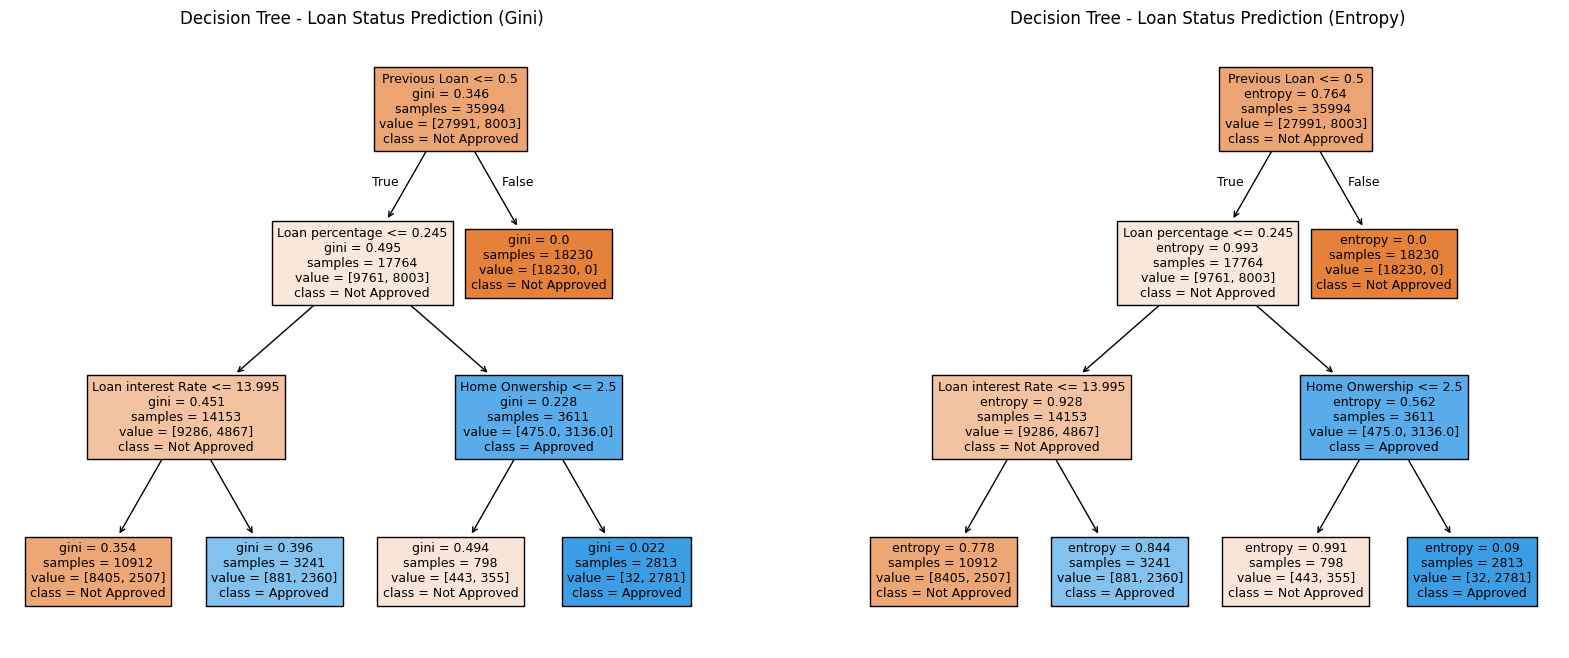

In [3]:
#Accuracy Check
#Decision Tree
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn import tree
df = pd.read_csv('loan_data_new.csv')
print(df)
df.head()
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['Loan Status'].value_counts())

# Drop outlier row (Age = 144 is clearly bad data) - added from original cell
df = df[df['Age'] < 100]

# Encode categorical columns - added LabelEncoder
label_cols = ['Gender', 'Education', 'Home Onwership', 'Loan Intent', 'Previous Loan']
le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])

y=df['Loan Status']
x=df.drop('Loan Status',axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
clf_gini = DecisionTreeClassifier(criterion = "gini", random_state = 100,max_depth=3, min_samples_leaf=5)
clf_gini.fit(x_train, y_train)
y_gini_pred=clf_gini.predict(x_test)
accuracy_gini = accuracy_score(y_test,y_gini_pred)*100
print("Accuracy with gini: ",accuracy_gini)
clf_entropy = DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 3, min_samples_leaf = 5)
clf_entropy.fit(x_train, y_train)
y_entropy_pred=clf_entropy.predict(x_test)
accuracy_entropy = accuracy_score(y_test,y_entropy_pred)*100
print("Accuracy with entropy: ",accuracy_entropy)
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
tree.plot_tree(clf_gini, feature_names=x.columns.tolist(), class_names=['Not Approved', 'Approved'], filled=True, fontsize=9) # Corrected plot_tree call
plt.title("Decision Tree - Loan Status Prediction (Gini)")
plt.subplot(1, 2, 2)
tree.plot_tree(clf_entropy, feature_names=x.columns.tolist(), class_names=['Not Approved', 'Approved'], filled=True, fontsize=9) # Corrected plot_tree call
plt.title("Decision Tree - Loan Status Prediction (Entropy)")
plt.show()

Accuracy: 0.8914444444444445

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.78      0.71      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000



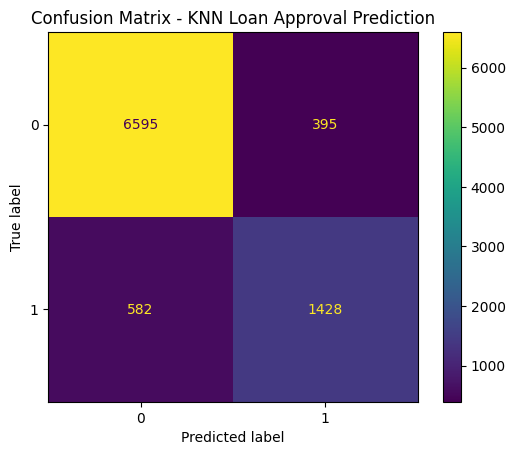

In [21]:
#KNN
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load dataset
data = pd.read_csv("/content/loan_data_new.csv")

# Remove missing values
data = data.dropna()

# Encode categorical columns
le = LabelEncoder()

categorical_columns = [
    'Gender',
    'Education',
    'Home Onwership',
    'Loan Intent',
    'Previous Loan'
]

for col in categorical_columns:
    data[col] = le.fit_transform(data[col])

# Encode target column
data['Loan Status'] = le.fit_transform(data['Loan Status'])

# Split features and target
X = data.drop('Loan Status', axis=1)
y = data['Loan Status']

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - KNN Loan Approval Prediction")
plt.show()

In [22]:
#Linear Regression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("loan_data_new.csv")
print(df.head())
y = df['Loan Status']
X = df.drop('Loan Status', axis=1)
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.fillna(X_encoded.median())
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Generate continuous predictions
y_pred_continuous = model.predict(X_test_scaled)

# Convert continuous predictions to binary (e.g., using a threshold of 0.5)
y_pred_binary = (y_pred_continuous > 0.5).astype(int)

results_df = X_test.copy()
results_df['Actual_Loan_Status'] = y_test
results_df['Predicted_Loan_Status'] = y_pred_binary
results_df['Raw_Regression_Score'] = y_pred_continuous
print("\n--- PREVIEW OF PREDICTIONS ---")
print(results_df[['Actual_Loan_Status', 'Predicted_Loan_Status', 'Raw_Regression_Score']].head(10))

accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy * 100:.2f}%")

   Age  Gender    Education  Person Income  Employee Experience  \
0   22  female       Master          71948                    0   
1   21  female  High School          12282                    0   
2   25  female  High School          12438                    3   
3   23  female     Bachelor          79753                    0   
4   24    male       Master          66135                    1   

  Home Onwership  Loan Amount Loan Intent  Loan interest Rate  \
0           RENT        35000    PERSONAL               16.02   
1            OWN         1000   EDUCATION               11.14   
2       MORTGAGE         5500     MEDICAL               12.87   
3           RENT        35000     MEDICAL               15.23   
4           RENT        35000     MEDICAL               14.27   

   Loan percentage  Credit History  Credit Score Previous Loan  Loan Status  
0             0.49               3           561            No            1  
1             0.08               2           504  

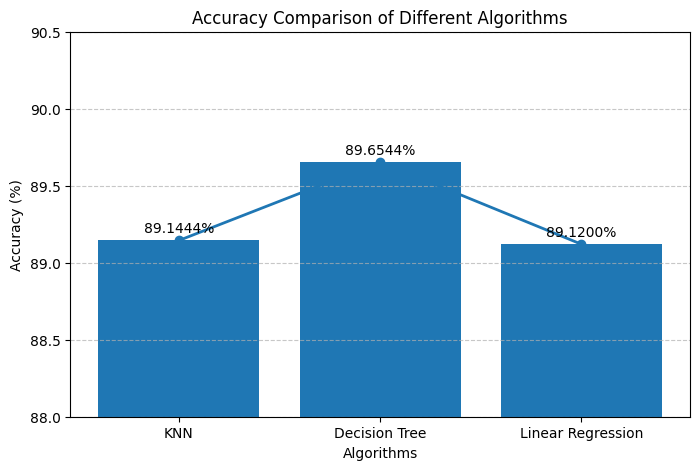

In [ ]:
#Accuracy Comparison Graph
import matplotlib.pyplot as plt

# Accuracy values
algorithms = ['KNN', 'Decision Tree', 'Linear Regression']
accuracies = [89.1444, 89.6544, 89.1200]

# Create figure
plt.figure(figsize=(8,5))

# Bar graph
bars = plt.bar(algorithms, accuracies)

# Line graph connecting the accuracies
plt.plot(algorithms, accuracies, marker='o', linewidth=2)

# Add accuracy labels
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.05, f'{acc:.4f}%', ha='center', fontsize=10)

# Labels and title
plt.xlabel('Algorithms')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison of Different Algorithms')

# Set y-axis limits for better visibility
plt.ylim(88, 90.5)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()